# TinyTCN: Architectural Proposal and Ablation Study for TinyML-Based Stress Detection
## Wrist-Worn Physiological Signals — Early Fusion of EDA and BVP (WESAD Dataset)

This notebook presents the design, empirical justification, and embedded
deployment pipeline for TinyTCN, a lightweight temporal convolutional network
proposed for binary stress classification from wrist-worn physiological
sensors. The experimental methodology is structured across three consecutive
stages. In the first stage, raw multimodal recordings from the WESAD benchmark
dataset are loaded, segmented, and transformed into a unified six-channel
early-fusion input representation. In the second stage, a two-part ablation
study is conducted: Part 1 isolates the marginal contribution of each
structural component of the proposed architecture, and Part 2 identifies the
optimal hyperparameter configuration of the confirmed full architecture through
a systematic axis-wise sweep. In the third stage, the model confirmed by
ablation is retrained on the full training partition, evaluated on a held-out
test set, and converted to TensorFlow Lite using three post-training
quantization strategies for microcontroller deployment. The ablation study
constitutes the primary empirical contribution of this work, providing a
principled and reproducible justification for each design decision embodied
in the TinyTCN architecture without recourse to external baseline comparison.

## Cell 1 — Environment Configuration and Experimental Parameters

All dependencies, directory structures, and experimental hyperparameters
governing the entirety of the subsequent pipeline are consolidated and
initialised in this cell. Centralising configuration in a single location
ensures that any modification to a parameter — whether pertaining to signal
processing, model architecture, or training procedure — propagates
consistently to all downstream cells without requiring manual synchronisation
across multiple definitions. The signal processing constants reflect the
sensor specifications of the WESAD wrist-worn device: the electrodermal
activity signal is recorded at 4 Hz and the blood volume pulse signal at
64 Hz, and both are subsequently resampled to a unified target rate of 8 Hz
prior to model input construction. This target rate is selected as it
represents the lowest common resolution that preserves physiologically
meaningful temporal structure in the BVP morphology while remaining
computationally tractable for embedded inference. The training configuration
— comprising five-fold stratified cross-validation, a batch size of 32, a
maximum of 100 epochs per fold, early stopping with a patience of 20 epochs,
and label smoothing of 0.1 — is chosen to balance training stability,
regularisation, and computational cost across the large number of
sequential model evaluations required by the ablation study. The baseline
TinyTCN hyperparameter dictionary, which specifies three residual blocks,
a base filter count of 16, a kernel size of 3, a Squeeze-and-Excitation
reduction ratio of 8, and a dropout rate of 0.2, defines the anchor
configuration held constant on all non-varied axes during the Part 2
hyperparameter sweep, ensuring that each axis is evaluated in isolation.
GPU memory growth is enabled where hardware acceleration is available to
prevent TensorFlow from occupying the full device memory at initialisation,
which would otherwise cause allocation failures across the successive model
instantiations required by the multi-run ablation protocol.

In [22]:
# ============================================================
# Cell 1 — Imports & Config
# ============================================================
import os
import gc
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from scipy import signal as scipy_signal
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score,
                             precision_recall_fscore_support,
                             confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────
WESAD_DIR  = 'dataset/WESAD'
SAVE_DIR   = 'tinytcn_ablation'
MODEL_DIR  = os.path.join(SAVE_DIR, 'models')
TFLITE_DIR = os.path.join(SAVE_DIR, 'tflite')
for d in [SAVE_DIR, MODEL_DIR, TFLITE_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Data parameters ──────────────────────────────────────────
EDA_HZ          = 4
BVP_HZ          = 64
TARGET_HZ       = 8
WINDOW_SEC      = 60
OVERLAP         = 0.5
INCLUDE_DERIV   = True     # 6-channel input: EDA,BVP,dEDA,dBVP,d2EDA,d2BVP

# ── Training parameters ──────────────────────────────────────
N_SPLITS        = 5
BATCH_SIZE      = 32
EPOCHS          = 100
LR              = 0.001
PATIENCE        = 20
LABEL_SMOOTH    = 0.1
TEST_SIZE       = 0.2
RANDOM_STATE    = 42

# ── Part 2 baseline hyperparams ─────────────────────────────
TCN_BASELINE = dict(
    num_blocks      = 3,
    base_filters    = 16,
    kernel_size     = 3,
    reduction_ratio = 8,
    dropout_rate    = 0.2,
)

# ── GPU config ───────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU ready ({len(gpus)} device(s))")
else:
    print("✓ Running on CPU")

print("✓ Config complete")

✓ Running on CPU
✓ Config complete


## Cell 2 — Subject-Level Data Loading from WESAD Pickle Files

The WESAD dataset is ingested in this cell by iterating over the
subject-level subdirectories of the dataset root and deserialising each
subject's pickle file using Latin-1 encoding, which is required by the
original dataset distribution format. For each subject, the electrodermal
activity and blood volume pulse signals are extracted from the wrist-sensor
branch of the nested data structure, in preference to the chest-worn
modality, on the grounds that wrist-worn sensors are more representative
of the hardware constraints encountered in consumer-grade TinyML deployment
scenarios. The label array, which is recorded by the WESAD protocol at a
native sampling frequency substantially higher than either physiological
signal, is downsampled to match both target signal rates through a
mode-based binning procedure: within each non-overlapping temporal bin
of appropriate width, the most frequently occurring label is selected as
the representative annotation for that bin. This approach preserves the
dominant protocol phase within each window rather than introducing
systematic label noise through simple decimation or nearest-neighbour
interpolation, which would be particularly problematic at phase transitions
between protocol segments. Contiguous signal segments annotated with label
one, corresponding to the neutral baseline condition, and label two,
corresponding to the stress induction condition, are extracted and stored
separately for each subject, while all remaining protocol phases — including
amusement, meditation, and recovery — are excluded to maintain the binary
classification formulation consistent with the research objective. The
preservation of subject-level data separation throughout this and all
subsequent preprocessing stages ensures that the cross-validation procedure
in the training cell correctly captures inter-subject physiological
variability without permitting data leakage between training and validation
partitions.

In [23]:
# ============================================================
# Cell 2 — Data Loading  (inline from module 0)
# ============================================================

def downsample_labels(labels, factor):
    """Take mode in each bin to downsample label array."""
    n = len(labels) // factor
    out = np.zeros(n, dtype=labels.dtype)
    for i in range(n):
        sl = labels[i*factor : min((i+1)*factor, len(labels))]
        out[i] = np.bincount(sl.astype(int)).argmax()
    return out


def extract_baseline_stress(eda, bvp, labels, subject_id):
    """
    Align labels to EDA (4 Hz) and BVP (64 Hz) then
    extract baseline (label=1) and stress (label=2) segments.
    """
    label_hz = (len(labels) / len(bvp)) * BVP_HZ

    labels_eda = downsample_labels(labels, int(label_hz / EDA_HZ))[:len(eda)]
    labels_bvp = downsample_labels(labels, int(label_hz / BVP_HZ))[:len(bvp)]

    result = {
        'eda_signal': {
            'baseline': eda[labels_eda == 1],
            'stress':   eda[labels_eda == 2],
        },
        'bvp_signal': {
            'baseline': bvp[labels_bvp == 1],
            'stress':   bvp[labels_bvp == 2],
        }
    }
    print(f"  {subject_id}: "
          f"EDA base={len(result['eda_signal']['baseline'])} "
          f"stress={len(result['eda_signal']['stress'])} | "
          f"BVP base={len(result['bvp_signal']['baseline'])} "
          f"stress={len(result['bvp_signal']['stress'])}")
    return result


def load_all_subjects(base_dir):
    """Load all WESAD pickle files and extract segments."""
    all_data = {}
    base_path = Path(base_dir)
    print(f"Loading from: {base_dir}")
    print("=" * 60)

    for folder in sorted(base_path.iterdir()):
        if not folder.is_dir():
            continue
        pkl_files = list(folder.glob('*.pkl'))
        if not pkl_files:
            continue
        try:
            with open(pkl_files[0], 'rb') as f:
                data = pickle.load(f, encoding='latin1')
            subject_id = data.get('subject', folder.name)
            eda = data['signal']['wrist']['EDA'].flatten()
            bvp = data['signal']['wrist']['BVP'].flatten()
            labels = data['label']
            all_data[subject_id] = extract_baseline_stress(
                eda, bvp, labels, subject_id)
        except Exception as e:
            print(f"  Error loading {pkl_files[0].name}: {e}")

    print("=" * 60)
    print(f"✓ Loaded {len(all_data)} subjects")
    return all_data


subjects_data = load_all_subjects(WESAD_DIR)

Loading from: dataset/WESAD
  S10: EDA base=4720 stress=2900 | BVP base=82600 stress=50750
  S11: EDA base=4720 stress=2720 | BVP base=82600 stress=47600
  S13: EDA base=4720 stress=2656 | BVP base=82600 stress=46479
  S14: EDA base=4720 stress=2700 | BVP base=82600 stress=47250
  S15: EDA base=4700 stress=2744 | BVP base=82250 stress=48020
  S16: EDA base=4720 stress=2692 | BVP base=82600 stress=47110
  S17: EDA base=4724 stress=2892 | BVP base=82670 stress=50610
  S2: EDA base=4576 stress=2460 | BVP base=80080 stress=43050
  S3: EDA base=4560 stress=2560 | BVP base=79800 stress=44800
  S4: EDA base=4632 stress=2540 | BVP base=81060 stress=44450
  S5: EDA base=4792 stress=2580 | BVP base=83860 stress=45150
  S6: EDA base=4720 stress=2600 | BVP base=82600 stress=45500
  S7: EDA base=4744 stress=2560 | BVP base=83020 stress=44800
  S8: EDA base=4676 stress=2680 | BVP base=81830 stress=46900
  S9: EDA base=4720 stress=2580 | BVP base=82600 stress=45150
✓ Loaded 15 subjects


## Cell 3 — Fixed-Length Sliding Window Segmentation

The continuous baseline and stress signal segments extracted in the preceding
cell are partitioned into fixed-length analysis windows in this cell, which
constitutes the standard transformation required to produce fixed-dimensional
inputs compatible with the convolutional architecture proposed in this study.
A window duration of 60 seconds is adopted to encompass the slow-varying
temporal dynamics characteristic of the electrodermal activity signal, which
exhibits physiologically meaningful sympathetic nervous system responses on
timescales ranging from several seconds to several minutes, and which would
be inadequately represented by shorter windows commonly used in
photoplethysmography-only analyses. A 50 percent overlap between consecutive
windows is applied to increase the effective number of training examples
available from each subject's recording without introducing fully independent
new observations, thereby augmenting the training distribution while
preserving the temporal structure and autocorrelation properties of the
underlying signal. Windowing is performed independently on the EDA and BVP
signals at their respective native sampling rates prior to resampling, in
order to avoid interpolation artefacts that would arise if resampling were
applied to the full continuous signal before segmentation. Following
windowing, the minimum window count across the two modalities is computed
per subject and used to truncate both window sets to equal length, ensuring
that all downstream early fusion operations pair only temporally
co-registered EDA and BVP windows from the same recording interval. The
output of this cell is a subject-indexed dictionary of aligned window sets
that serves as the direct input to the early fusion data construction stage.

In [24]:
# ============================================================
# Cell 3 — Windowing  (inline from module 1)
# ============================================================

def make_windows(signal, hz, window_sec=WINDOW_SEC, overlap=OVERLAP):
    """Sliding windows with overlap from a 1-D signal array."""
    win  = int(window_sec * hz)
    step = int(win * (1 - overlap))
    return [signal[i:i+win]
            for i in range(0, len(signal) - win + 1, step)]


def build_windowed_dataset(subjects_data):
    """Return per-subject dict of windowed EDA and BVP segments."""
    windowed = {}
    print("Creating windows …")
    for sid, data in subjects_data.items():
        wb = {}
        for sig in ('eda_signal', 'bvp_signal'):
            hz = EDA_HZ if sig == 'eda_signal' else BVP_HZ
            wb[sig] = {
                split: make_windows(data[sig][split], hz)
                for split in ('baseline', 'stress')
            }
        n_base = min(len(wb['eda_signal']['baseline']),
                     len(wb['bvp_signal']['baseline']))
        n_stress = min(len(wb['eda_signal']['stress']),
                       len(wb['bvp_signal']['stress']))
        windowed[sid] = {
            'eda': {'baseline': wb['eda_signal']['baseline'][:n_base],
                    'stress':   wb['eda_signal']['stress'][:n_stress]},
            'bvp': {'baseline': wb['bvp_signal']['baseline'][:n_base],
                    'stress':   wb['bvp_signal']['stress'][:n_stress]},
        }
        print(f"  {sid}: base={n_base} windows, stress={n_stress} windows")
    print("✓ Windowing complete")
    return windowed


windowed_data = build_windowed_dataset(subjects_data)

Creating windows …
  S10: base=38 windows, stress=23 windows
  S11: base=38 windows, stress=21 windows
  S13: base=38 windows, stress=21 windows
  S14: base=38 windows, stress=21 windows
  S15: base=38 windows, stress=21 windows
  S16: base=38 windows, stress=21 windows
  S17: base=38 windows, stress=23 windows
  S2: base=37 windows, stress=19 windows
  S3: base=37 windows, stress=20 windows
  S4: base=37 windows, stress=20 windows
  S5: base=38 windows, stress=20 windows
  S6: base=38 windows, stress=20 windows
  S7: base=38 windows, stress=20 windows
  S8: base=37 windows, stress=21 windows
  S9: base=38 windows, stress=20 windows
✓ Windowing complete


## Cell 4 — Early Fusion Input Construction, Normalisation, and Data Splitting

The six-channel early fusion input tensor is constructed in this cell by
combining resampled EDA and BVP windows with their respective temporal
derivatives into a unified multichannel representation that is subsequently
normalised and partitioned for training and evaluation. Each paired EDA and
BVP window is independently resampled to the common target rate of 8 Hz
using polyphase filtering as implemented in the SciPy signal processing
library: the 4 Hz EDA window is upsampled by a factor of two, and the
64 Hz BVP window is downsampled by a factor of eight. The first and second
temporal derivatives of each resampled signal are computed via central finite
differences and appended as additional input channels alongside the raw
signals, yielding a final input tensor of shape 480 × 6. The motivation for
derivative inclusion is grounded in physiological signal theory: the first
derivative of the EDA signal captures the rate of change of skin conductance,
which is associated with the onset and offset of sympathetic arousal
responses, while the second derivative captures inflection points
corresponding to rapid autonomic transitions. Similarly, BVP derivatives
encode pulse rate variability and waveform morphology features that have been
demonstrated to be discriminative for stress classification in prior
literature. Windows are assigned binary labels of zero for baseline and one
for stress before concatenation into a single dataset array. A global
z-score normalisation is applied channel-wise across the full dataset to
standardise the magnitude and variance of each input dimension, after which
a stratified 80/20 train-test split is performed using a fixed random seed
to ensure reproducibility. The held-out test partition is not accessed at
any subsequent stage until the final evaluation in Cell 11, maintaining
the integrity of the performance estimate reported for the confirmed model.

In [25]:
# ============================================================
# Cell 4 — Early Fusion Data Preparation
# ============================================================

def resample(sig, src_hz, tgt_hz):
    if src_hz == tgt_hz:
        return sig
    n = int(len(sig) * tgt_hz / src_hz)
    return scipy_signal.resample(sig, n)


def make_6channel(eda_win, bvp_win):
    """
    Resample both signals to TARGET_HZ then stack:
    [EDA, BVP, dEDA/dt, dBVP/dt, d²EDA/dt², d²BVP/dt²]
    """
    e = resample(eda_win, EDA_HZ, TARGET_HZ)
    b = resample(bvp_win, BVP_HZ, TARGET_HZ)
    de,  db  = np.gradient(e),  np.gradient(b)
    d2e, d2b = np.gradient(de), np.gradient(db)
    return np.stack([e, b, de, db, d2e, d2b], axis=-1)


def build_early_fusion(windowed_data):
    X_list, y_list = [], []
    for sid in windowed_data:
        for label, split in enumerate(['baseline', 'stress']):
            for eda_w, bvp_w in zip(windowed_data[sid]['eda'][split],
                                     windowed_data[sid]['bvp'][split]):
                X_list.append(make_6channel(eda_w, bvp_w))
                y_list.append(label)
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    print(f"Dataset shape : {X.shape}")
    print(f"Baseline      : {np.sum(y==0)}  |  Stress: {np.sum(y==1)}")
    return X, y


X_all, y_all = build_early_fusion(windowed_data)

# Global z-score normalisation
mean_g = X_all.mean(axis=(0, 1), keepdims=True)
std_g  = X_all.std(axis=(0, 1),  keepdims=True) + 1e-8
X_norm = (X_all - mean_g) / std_g

# Train / test split — held-out test set used only at the very end
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE
)

INPUT_SHAPE = X_train.shape[1:]   # (480, 6)
print(f"\nTrain : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Input shape for models : {INPUT_SHAPE}")

Dataset shape : (877, 480, 6)
Baseline      : 566  |  Stress: 311

Train : (701, 480, 6)  |  Test : (176, 480, 6)
Input shape for models : (480, 6)


## Cell 5 — Shared Stratified K-Fold Cross-Validation Training Procedure

A unified training and evaluation function is defined in this cell and
applied without modification to every model configuration evaluated in both
parts of the ablation study, ensuring that observed differences in
classification performance are attributable exclusively to architectural
or hyperparameter variation rather than to inconsistencies in the training
protocol. Stratified five-fold cross-validation is employed so that the
proportion of baseline and stress windows is preserved identically across
all training and validation partitions, which is particularly important
given the potential for class imbalance arising from the unequal duration
of the baseline and stress conditions in the WESAD experimental protocol.
Within each fold, a secondary z-score normalisation is applied using
statistics computed exclusively from the training subset of that fold,
thereby preventing any statistical information from the validation subset
from influencing the input scaling and ensuring strict absence of data
leakage. Label smoothing of 0.1 is applied to the one-hot encoded training
targets by redistributing a fraction of the probability mass from the
correct class to all classes uniformly, which has been demonstrated to
improve classifier calibration and reduce overconfident softmax predictions
in low-data physiological signal classification regimes. The Adam optimiser
with gradient norm clipping at unit norm is employed in conjunction with a
ReduceLROnPlateau learning rate schedule that halves the learning rate upon
validation loss stagnation, and early stopping with patience of 20 epochs
restores the best-observed model weights to prevent overfitting beyond the
optimal training point. The best-performing checkpoint, as determined by
validation loss, is saved to disk and reloaded before evaluation to ensure
that reported metrics correspond to the optimal point in the training
trajectory. The fold-level F1-scores and accuracy values are aggregated
to produce mean and standard deviation performance estimates, and the model
from the fold achieving the highest F1-score is retained as the
representative instance for that configuration, to be used in any subsequent
inference operations requiring a single model.

In [26]:
# ============================================================
# Cell 5 — Shared K-Fold Trainer
# ============================================================

def run_kfold(X, y, model_fn, run_name, save_tag):
    """
    5-fold stratified CV.
    Returns dict with mean/std metrics, param count,
    and the best fold's model (loaded from checkpoint).
    """
    skf = StratifiedKFold(n_splits=N_SPLITS,
                          shuffle=True,
                          random_state=RANDOM_STATE)
    fold_metrics = []
    best_f1, best_model = 0.0, None

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        keras.backend.clear_session()
        gc.collect()

        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # Per-fold standardisation on top of global norm
        mu  = X_tr.mean(axis=(0, 1), keepdims=True)
        sig = X_tr.std(axis=(0, 1),  keepdims=True) + 1e-8
        X_tr  = (X_tr  - mu) / sig
        X_val = (X_val - mu) / sig

        # Label smoothing
        y_tr_cat  = to_categorical(y_tr,  2) * (1-LABEL_SMOOTH) \
                    + LABEL_SMOOTH / 2
        y_val_cat = to_categorical(y_val, 2)

        model = model_fn()
        model.compile(
            optimizer=optimizers.Adam(LR, clipnorm=1.0),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        ckpt = os.path.join(MODEL_DIR,
                            f'{save_tag}_fold{fold}.keras')
        cb_list = [
            callbacks.EarlyStopping(
                monitor='val_loss', patience=PATIENCE,
                restore_best_weights=True),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=8, min_lr=1e-6, verbose=0),
            callbacks.ModelCheckpoint(
                ckpt, monitor='val_loss',
                save_best_only=True, verbose=0),
        ]

        model.fit(
            X_tr, y_tr_cat,
            validation_data=(X_val, y_val_cat),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=cb_list,
            verbose=0
        )

        # Reload best checkpoint
        model = keras.models.load_model(ckpt)

        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        acc = accuracy_score(y_val, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_val, y_pred, average='binary', zero_division=0)

        fold_metrics.append(
            {'fold': fold, 'acc': acc,
             'prec': prec, 'rec': rec, 'f1': f1})
        print(f"  [{run_name}] fold {fold}: "
              f"Acc={acc:.4f}  F1={f1:.4f}")

        if f1 > best_f1:
            best_f1    = f1
            best_model = model

    params = best_model.count_params()
    accs   = [m['acc']  for m in fold_metrics]
    f1s    = [m['f1']   for m in fold_metrics]
    precs  = [m['prec'] for m in fold_metrics]
    recs   = [m['rec']  for m in fold_metrics]

    return {
        'run_name':  run_name,
        'mean_acc':  np.mean(accs),  'std_acc':  np.std(accs),
        'mean_f1':   np.mean(f1s),   'std_f1':   np.std(f1s),
        'mean_prec': np.mean(precs), 'mean_rec': np.mean(recs),
        'params':    params,
        'best_model': best_model,
        'fold_f1s':   f1s,
    }

## Cell 6 — TinyTCN Architecture Definition

The TinyTCN architecture is defined in this cell through three modular
functional components, each of which corresponds directly to one of the
structural design principles stated in the architectural proposal, and
a single factory function that assembles them into a complete Keras
functional model. The residual block function implements the first and
fourth design principles — residual connectivity and exclusive use of
standard layer types — by connecting two sequential Conv1D layers, each
followed by batch normalisation and ReLU6 activation, through a skip
connection that adds the block input to the block output. When the number
of input and output channels differs, a 1×1 projection convolution is
applied to the shortcut path to match dimensions, following the convention
established in the original ResNet formulation. The adoption of ReLU6,
which clamps activations to the interval [0, 6], is motivated by its
established compatibility with integer quantization: by bounding activation
magnitudes, it prevents large outlier values from dominating the per-layer
quantization scale and thereby reduces quantization error across the
activation tensor. The channel attention function implements the third
design principle through a Squeeze-and-Excitation formulation expressed
entirely in standard Keras operations: the temporal dimension is collapsed
by global average pooling to produce a channel descriptor vector, which
is passed through two fully connected layers with ReLU and sigmoid
activations respectively to produce a per-channel recalibration weight,
and the resulting weight vector is reshaped and multiplied element-wise
with the input feature map to selectively amplify discriminative channels.
Critically, both components are implemented exclusively using standard Keras
functional API layer calls without any subclassed layer definitions, which
is a strict requirement for compatibility with TensorFlow Model Optimization
Toolkit quantization-aware training and the TFLite conversion routines
applied in Cell 12. The factory function exposes Boolean flags for each
structural component — use_residual, use_attention, and use_pooling —
enabling the generation of all four component ablation variants in Part 1
from a single code path, while the numerical hyperparameters support the
systematic axis-wise sweep conducted in Part 2.

In [27]:
# ============================================================
# Cell 6 — TinyTCN Architecture
# ============================================================

# ── Building blocks ──────────────────────────────────────────

def residual_block(x, filters, kernel_size, dropout_rate, pfx):
    """
    Two Conv1D + BN + ReLU6 with residual skip.
    1×1 projection when channel dims differ.
    All standard layers → QAT-compatible.
    """
    shortcut = x
    out = layers.Conv1D(filters, kernel_size, padding='same',
                        use_bias=False, name=f'{pfx}_c1')(x)
    out = layers.BatchNormalization(name=f'{pfx}_bn1')(out)
    out = layers.ReLU(max_value=6.0,  name=f'{pfx}_r1')(out)
    out = layers.Dropout(dropout_rate, name=f'{pfx}_drop')(out)
    out = layers.Conv1D(filters, kernel_size, padding='same',
                        use_bias=False, name=f'{pfx}_c2')(out)
    out = layers.BatchNormalization(name=f'{pfx}_bn2')(out)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same',
                                 use_bias=False,
                                 name=f'{pfx}_proj')(shortcut)
    out = layers.Add(name=f'{pfx}_add')([out, shortcut])
    out = layers.ReLU(max_value=6.0, name=f'{pfx}_r2')(out)
    return out


def se_attention(x, reduction_ratio, pfx):
    """
    Squeeze-and-Excitation channel attention.
    GlobalAveragePooling1D → Dense → Dense → Reshape → Multiply.
    No custom layer class → QAT-compatible.
    """
    ch      = x.shape[-1]
    reduced = max(1, ch // reduction_ratio)
    se = layers.GlobalAveragePooling1D(name=f'{pfx}_sq')(x)
    se = layers.Dense(reduced, activation='relu',
                      name=f'{pfx}_fc1')(se)
    se = layers.Dense(ch, activation='sigmoid',
                      name=f'{pfx}_fc2')(se)
    se = layers.Reshape((1, ch), name=f'{pfx}_rs')(se)
    return layers.Multiply(name=f'{pfx}_mul')([x, se])


# ── Full TinyTCN factory ─────────────────────────────────────

def build_tiny_tcn(input_shape,
                   num_classes    = 2,
                   num_blocks     = 3,
                   base_filters   = 16,
                   kernel_size    = 3,
                   dropout_rate   = 0.2,
                   reduction_ratio= 8,
                   use_residual   = True,
                   use_attention  = True,
                   use_pooling    = True,
                   model_name     = 'TinyTCN'):
    """
    Configurable TinyTCN for both Part 1 (component flags)
    and Part 2 (hyperparameter sweep).

    Filter progression: base → base*2 → base*4 … (capped at 128)
    Progressive MaxPooling1D(2) between all but the last block.
    """
    inputs = layers.Input(shape=input_shape, name='input')

    # Entry conv
    x = layers.Conv1D(base_filters, kernel_size, padding='same',
                      use_bias=False, name='entry_conv')(inputs)
    x = layers.BatchNormalization(name='entry_bn')(x)
    x = layers.ReLU(max_value=6.0,  name='entry_relu')(x)

    current_filters = base_filters

    for i in range(num_blocks):
        pfx = f'b{i+1}'

        if use_residual:
            x = residual_block(x, current_filters,
                               kernel_size, dropout_rate, pfx)
        else:
            # Plain conv path (V1 baseline — same filter progression)
            x = layers.Conv1D(current_filters, kernel_size,
                              padding='same', use_bias=False,
                              name=f'{pfx}_pc')(x)
            x = layers.BatchNormalization(name=f'{pfx}_pbn')(x)
            x = layers.ReLU(max_value=6.0, name=f'{pfx}_pr')(x)
            x = layers.Dropout(dropout_rate, name=f'{pfx}_pdrop')(x)

        if use_attention:
            x = se_attention(x, reduction_ratio, f'attn{i+1}')

        # Progressive downsampling between blocks (not after last)
        if use_pooling and i < num_blocks - 1:
            x = layers.MaxPooling1D(2, name=f'pool{i+1}')(x)
            current_filters = min(current_filters * 2, 128)

    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(32, name='head_fc')(x)
    x = layers.ReLU(max_value=6.0, name='head_relu')(x)
    x = layers.Dropout(dropout_rate, name='head_drop')(x)
    out = layers.Dense(num_classes, activation='softmax',
                       name='output')(x)

    return keras.Model(inputs, out, name=model_name)


# Quick sanity check
_m = build_tiny_tcn(INPUT_SHAPE)
print(f"TinyTCN (baseline config) — params: {_m.count_params():,}")
_m.summary(line_length=72)
keras.backend.clear_session()

TinyTCN (baseline config) — params: 32,000


Model: "TinyTCN"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape     ┃   Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer) │ (None, 480, 6)   │         0 │ -                │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ entry_conv         │ (None, 480, 16)  │       288 │ input[0][0]      │
│ (Conv1D)           │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ entry_bn           │ (None, 480, 16)  │        64 │ entry_conv[0][0] │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ entry_relu (ReLU)  │ (None, 480, 16)  │         0 │ entry_bn[0][0]   │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_c1 (Conv1D)     │ (None, 480, 16)  │       768 │ entry_relu[0][0] │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_bn1             │ (None, 480, 16)  │        64 │ b1_c1[0][0]      │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_r1 (ReLU)       │ (None, 480, 16)  │         0 │ b1_bn1[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_drop (Dropout)  │ (None, 480, 16)  │         0 │ b1_r1[0][0]      │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_c2 (Conv1D)     │ (None, 480, 16)  │       768 │ b1_drop[0][0]    │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_bn2             │ (None, 480, 16)  │        64 │ b1_c2[0][0]      │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_add (Add)       │ (None, 480, 16)  │         0 │ b1_bn2[0][0],    │
│                    │                  │           │ entry_relu[0][0] │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_r2 (ReLU)       │ (None, 480, 16)  │         0 │ b1_add[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_sq           │ (None, 16)       │         0 │ b1_r2[0][0]      │
│ (GlobalAveragePoo… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_fc1 (Dense)  │ (None, 2)        │        34 │ attn1_sq[0][0]   │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_fc2 (Dense)  │ (None, 16)       │        48 │ attn1_fc1[0][0]  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_rs (Reshape) │ (None, 1, 16)    │         0 │ attn1_fc2[0][0]  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_mul          │ (None, 480, 16)  │         0 │ b1_r2[0][0],     │
│ (Multiply)         │                  │           │ attn1_rs[0][0]   │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ pool1              │ (None, 240, 16)  │         0 │ attn1_mul[0][0]  │
│ (MaxPooling1D)     │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_c1 (Conv1D)     │ (None, 240, 32)  │     1,536 │ pool1[0][0]      │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_bn1             │ (None, 240, 32)  │       128 │ b2_c1[0][0]      │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_r1 (ReLU)       │ (None, 240, 32)  │         0 │ b2_bn1[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_drop (Dropout)  │ (None, 240, 32)  │         0 │ b2_r

 Total params: 32,000 (125.00 KB)

 Trainable params: 31,520 (123.12 KB)

 Non-trainable params: 480 (1.88 KB)

## Cell 7 — Part 1: Component Ablation Study

The first part of the ablation study is conducted in this cell to provide
direct empirical evidence for each of the three structural additions that
distinguish the full TinyTCN from a plain convolutional network. Four model
variants are constructed and evaluated sequentially using the shared
cross-validation procedure defined in Cell 5, with each variant differing
from its predecessor by the addition of exactly one architectural component
while all other settings — including the baseline hyperparameter
configuration, the filter doubling schedule, the training procedure, and
the random seeds — are held invariant. This additive design ensures that
the F1-score difference between consecutive variants provides an unconfounded
estimate of the marginal contribution of the added component. Variant V1
constitutes the plain convolutional baseline: it applies the same entry
convolution and progressive filter count as the full model but replaces each
residual block with a single Conv1D-BatchNorm-ReLU-Dropout sequence and
omits both the channel attention mechanism and the progressive MaxPooling1D
stages. The deliberate use of the same filter progression in V1 as in the
full model ensures that the baseline is not trivially disadvantaged by a
reduced parameter count, thereby isolating structural contributions rather
than conflating them with capacity differences. Variant V2 introduces
residual skip connections to the convolutional blocks, enabling gradient
flow through identity paths and reducing the effective optimisation
difficulty when training on limited physiological data. Variant V3
additionally incorporates the Squeeze-and-Excitation channel attention
mechanism at the output of each residual block, enabling the network to
dynamically recalibrate the relative importance of EDA-derived and
BVP-derived feature channels at each processing stage. Variant V4
constitutes the complete TinyTCN by enabling progressive temporal
downsampling via MaxPooling1D between successive blocks, which reduces
the activation map length at each stage, lowers the computational cost
of subsequent convolutions, and introduces a degree of local temporal
translation invariance that has been shown to improve generalisation in
time-series classification. The incremental F1-score gain between
consecutive variants provides the quantitative basis for justifying the
inclusion of each component in the proposed architecture.

In [28]:
# ============================================================
# Cell 7 — Part 1: Component Ablation
#
# Four variants, built on the SAME filter progression.
# One component is added per step so each delta is isolated.
#
#  V1  plain conv only          (no residual, no attention, no pool)
#  V2  + residual connections   (no attention, no pool)
#  V3  + channel attention      (no pool)
#  V4  full TinyTCN             (residual + attention + pooling)
# ============================================================

COMPONENT_VARIANTS = [
    dict(use_residual=False, use_attention=False,
         use_pooling=False, label='V1_plain_conv'),
    dict(use_residual=True,  use_attention=False,
         use_pooling=False, label='V2_plus_residual'),
    dict(use_residual=True,  use_attention=True,
         use_pooling=False, label='V3_plus_attention'),
    dict(use_residual=True,  use_attention=True,
         use_pooling=True,  label='V4_full_TinyTCN'),
]

component_results = []

for v in COMPONENT_VARIANTS:
    print(f"\n{'='*60}")
    print(f"Part 1 | {v['label']}")
    print(f"  residual={v['use_residual']}  "
          f"attention={v['use_attention']}  "
          f"pooling={v['use_pooling']}")
    print(f"{'='*60}")

    def make_variant(cfg=v):
        return build_tiny_tcn(
            input_shape     = INPUT_SHAPE,
            num_blocks      = TCN_BASELINE['num_blocks'],
            base_filters    = TCN_BASELINE['base_filters'],
            kernel_size     = TCN_BASELINE['kernel_size'],
            dropout_rate    = TCN_BASELINE['dropout_rate'],
            reduction_ratio = TCN_BASELINE['reduction_ratio'],
            use_residual    = cfg['use_residual'],
            use_attention   = cfg['use_attention'],
            use_pooling     = cfg['use_pooling'],
            model_name      = cfg['label']
        )

    res = run_kfold(X_train, y_train,
                    make_variant,
                    run_name=v['label'],
                    save_tag=f"p1_{v['label']}")
    res.update({k: v[k] for k in
                ['use_residual', 'use_attention', 'use_pooling']})
    component_results.append(res)

    print(f"  → Acc: {res['mean_acc']:.4f}±{res['std_acc']:.4f}  "
          f"F1: {res['mean_f1']:.4f}±{res['std_f1']:.4f}  "
          f"Params: {res['params']:,}")

comp_df = pd.DataFrame([{
    'variant':      r['run_name'],
    'residual':     r['use_residual'],
    'attention':    r['use_attention'],
    'pooling':      r['use_pooling'],
    'mean_acc':     r['mean_acc'],
    'std_acc':      r['std_acc'],
    'mean_f1':      r['mean_f1'],
    'std_f1':       r['std_f1'],
    'mean_prec':    r['mean_prec'],
    'mean_rec':     r['mean_rec'],
    'params':       r['params'],
} for r in component_results])

comp_df.to_csv(f'{SAVE_DIR}/part1_component_ablation.csv', index=False)
print("\n✓ Part 1 complete — saved to part1_component_ablation.csv")
print(comp_df[['variant','mean_f1','std_f1','params']].to_string(index=False))


Part 1 | V1_plain_conv
  residual=False  attention=False  pooling=False
  [V1_plain_conv] fold 1: Acc=0.9716  F1=0.9600
  [V1_plain_conv] fold 2: Acc=0.9857  F1=0.9796
  [V1_plain_conv] fold 3: Acc=0.9357  F1=0.9011
  [V1_plain_conv] fold 4: Acc=0.9786  F1=0.9697
  [V1_plain_conv] fold 5: Acc=0.9357  F1=0.9109
  → Acc: 0.9615±0.0215  F1: 0.9443±0.0320  Params: 3,458

Part 1 | V2_plus_residual
  residual=True  attention=False  pooling=False
  [V2_plus_residual] fold 1: Acc=0.9645  F1=0.9495
  [V2_plus_residual] fold 2: Acc=0.9929  F1=0.9899
  [V2_plus_residual] fold 3: Acc=0.9857  F1=0.9800
  [V2_plus_residual] fold 4: Acc=0.9714  F1=0.9592
  [V2_plus_residual] fold 5: Acc=0.9357  F1=0.9126
  → Acc: 0.9701±0.0199  F1: 0.9582±0.0270  Params: 5,954

Part 1 | V3_plus_attention
  residual=True  attention=True  pooling=False
  [V3_plus_attention] fold 1: Acc=0.9574  F1=0.9400
  [V3_plus_attention] fold 2: Acc=0.9857  F1=0.9792
  [V3_plus_attention] fold 3: Acc=0.9857  F1=0.9800
  [V3_plus_a

## Cell 8 — Part 1: Results Quantification and Visualisation

The outcomes of the component ablation study are quantified and visualised
in this cell through three complementary representations designed to
communicate the empirical justification for the TinyTCN architecture at
multiple levels of granularity. The F1-score and accuracy bar charts present
the mean cross-validation performance of each variant alongside standard
deviation error bars derived from the five-fold evaluation distribution,
providing a direct assessment of both absolute performance and consistency
across data partitions. The stability of a configuration across folds, as
reflected in the width of the error bars, is of independent importance
from its mean performance, as a variant that achieves high mean accuracy
with high variance may not generalise reliably to new subject recordings.
The incremental contribution chart constitutes the primary analytical output
of Part 1: it plots the absolute F1-score gain attributable to each
architectural addition relative to the preceding variant, thereby
disaggregating the total performance of the full model into the separate
contributions of residual connectivity, channel attention, and progressive
downsampling. A positive gain at each transition provides affirmative
evidence that the corresponding component is non-redundant and contributes
independently to classification performance in the stress detection task
under study. Conversely, a negligible or negative gain at any transition
would constitute evidence against the corresponding design decision and
would necessitate a revision of the architectural rationale. The numerical
summary printed below the visualisations provides the exact values that
would be reported in the results section of a research paper describing
this work, including the baseline F1-score achieved by the plain
convolutional network and the cumulative gain attributable to each
successive component. The full TinyTCN confirmed by Part 1 is then
carried forward to Part 2 as a fixed architecture whose optimal
hyperparameter configuration remains to be determined.

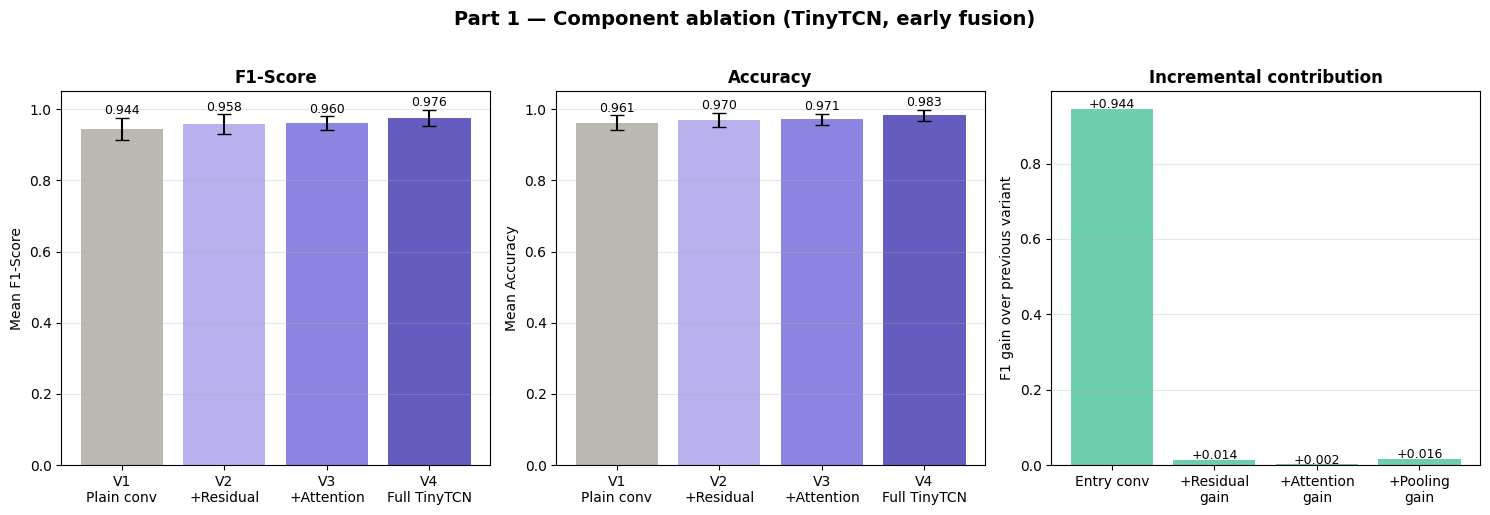

✓ Part 1 plot saved

Component contribution summary:
  Plain conv alone       : F1 = 0.9443
  Residual adds          : ΔF1 = +0.0140
  Channel attention adds : ΔF1 = +0.0019
  Progressive pooling adds: ΔF1 = +0.0159
  Full TinyTCN (V4)      : F1 = 0.9761


In [29]:
# ============================================================
# Cell 8 — Part 1 Results & Visualisation
# ============================================================

labels_short = ['V1\nPlain conv', 'V2\n+Residual',
                'V3\n+Attention', 'V4\nFull TinyTCN']
x_pos = np.arange(4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Part 1 — Component ablation (TinyTCN, early fusion)',
             fontsize=14, fontweight='bold', y=1.02)

# F1
axes[0].bar(x_pos, comp_df['mean_f1'],
            yerr=comp_df['std_f1'], capsize=5,
            color=['#B4B2A9','#AFA9EC','#7F77DD','#534AB7'],
            alpha=0.9)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(labels_short)
axes[0].set_ylabel('Mean F1-Score'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('F1-Score', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (val, std) in enumerate(
        zip(comp_df['mean_f1'], comp_df['std_f1'])):
    axes[0].text(i, val + std + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)

# Accuracy
axes[1].bar(x_pos, comp_df['mean_acc'],
            yerr=comp_df['std_acc'], capsize=5,
            color=['#B4B2A9','#AFA9EC','#7F77DD','#534AB7'],
            alpha=0.9)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(labels_short)
axes[1].set_ylabel('Mean Accuracy'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (val, std) in enumerate(
        zip(comp_df['mean_acc'], comp_df['std_acc'])):
    axes[1].text(i, val + std + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)

# Incremental F1 gain per component
gains = np.diff([0] + comp_df['mean_f1'].tolist())
gain_labels = ['Entry conv', '+Residual\ngain',
               '+Attention\ngain', '+Pooling\ngain']
colors_g = ['#5DCAA5' if g >= 0 else '#F0997B' for g in gains]
axes[2].bar(np.arange(4), gains, color=colors_g, alpha=0.9)
axes[2].set_xticks(np.arange(4))
axes[2].set_xticklabels(gain_labels)
axes[2].set_ylabel('F1 gain over previous variant')
axes[2].set_title('Incremental contribution', fontweight='bold')
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[2].grid(axis='y', alpha=0.3)
for i, g in enumerate(gains):
    axes[2].text(i, g + 0.002 if g >= 0 else g - 0.01,
                 f'{g:+.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/part1_component_ablation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Part 1 plot saved")

# Print component contribution summary
print("\nComponent contribution summary:")
print(f"  Plain conv alone       : F1 = {comp_df.iloc[0]['mean_f1']:.4f}")
print(f"  Residual adds          : ΔF1 = {gains[1]:+.4f}")
print(f"  Channel attention adds : ΔF1 = {gains[2]:+.4f}")
print(f"  Progressive pooling adds: ΔF1 = {gains[3]:+.4f}")
print(f"  Full TinyTCN (V4)      : F1 = {comp_df.iloc[3]['mean_f1']:.4f}")

## Cell 9 — Part 2: Hyperparameter Ablation Study

Having established in Part 1 that all three structural components of the
proposed architecture contribute positively to classification performance,
Part 2 treats the full TinyTCN as a fixed architectural template and
conducts a systematic axis-wise exploration of its five numerical
hyperparameters to identify the configuration that maximises generalisation
performance on the stress detection task. The sweep follows the
one-factor-at-a-time protocol, in which each hyperparameter axis is varied
across a predefined set of candidate values while all remaining axes are
held at the baseline values specified in Cell 1. Although this protocol does
not capture second-order interaction effects between hyperparameters, it
provides an interpretable and computationally tractable characterisation of
each axis's influence on model performance for the dataset and signal
modality under investigation, and is consistent with standard ablation
methodology in the TinyML and physiological computing literature. The depth
axis, varied across one to five residual blocks, determines the effective
temporal receptive field of the network and the depth of the learned feature
hierarchy, with deeper networks capable of capturing longer-range temporal
dependencies at the cost of increased parameter count and potential
optimisation difficulty on small datasets. The width axis, varied across
base filter counts of 8, 16, 32, and 64, controls the channel capacity at
the first processing stage and propagates multiplicatively through the filter
doubling schedule applied at each progressive pooling stage. The kernel size
axis, varied across 3, 5, 7, and 9 time steps, determines the span of local
temporal context captured by each convolutional operation within a block.
The reduction ratio axis, varied across 4, 8, 16, and 32, controls the
bottleneck dimension of the Squeeze-and-Excitation attention module relative
to the number of input channels, with higher ratios producing fewer attention
parameters. The dropout rate axis, varied across 0.1, 0.2, 0.3, and 0.4,
explores the regularisation strength applied uniformly within residual blocks
and the classification head. A deduplication step is applied prior to
execution to ensure that the baseline configuration, which appears as one
candidate value on every axis, is trained only once, avoiding redundant
computation and preventing repeated baseline results from artificially
inflating the reported cross-validation statistics.

In [30]:
# ============================================================
# Cell 9 — Part 2: Hyperparameter Ablation
#
# Full TinyTCN (V4) fixed. One axis varied at a time.
# Baseline config held constant on all other axes.
# ============================================================

hyper_experiments = []

# Axis 1: Depth — number of residual blocks
for nb in [1, 2, 3, 4, 5]:
    hyper_experiments.append({
        **TCN_BASELINE, 'num_blocks': nb,
        'label': f'tcn_blocks_{nb}'})

# Axis 2: Width — base filter count
# (doubles per block up to 128, so this is the capacity knob)
for bf in [8, 16, 32, 64]:
    hyper_experiments.append({
        **TCN_BASELINE, 'base_filters': bf,
        'label': f'tcn_filters_{bf}'})

# Axis 3: Kernel size — local temporal context per conv
for ks in [3, 5, 7, 9]:
    hyper_experiments.append({
        **TCN_BASELINE, 'kernel_size': ks,
        'label': f'tcn_kernel_{ks}'})

# Axis 4: SE reduction ratio — attention bottleneck
# Larger = smaller bottleneck = fewer attention params
for rr in [4, 8, 16, 32]:
    hyper_experiments.append({
        **TCN_BASELINE, 'reduction_ratio': rr,
        'label': f'tcn_reduction_{rr}'})

# Axis 5: Dropout rate — regularisation strength
for dr in [0.1, 0.2, 0.3, 0.4]:
    hyper_experiments.append({
        **TCN_BASELINE, 'dropout_rate': dr,
        'label': f'tcn_dropout_{dr}'})

# Deduplicate (baseline appears once per axis)
seen, hyper_deduped = set(), []
for exp in hyper_experiments:
    key = (exp['num_blocks'], exp['base_filters'],
           exp['kernel_size'], exp['reduction_ratio'],
           exp['dropout_rate'])
    if key not in seen:
        seen.add(key)
        hyper_deduped.append(exp)

print(f"Total Part 2 runs: {len(hyper_deduped)}")

hyper_results = []

for exp in hyper_deduped:
    print(f"\n{'='*60}")
    print(f"Part 2 | {exp['label']}")
    print(f"  blocks={exp['num_blocks']}  filters={exp['base_filters']}  "
          f"kernel={exp['kernel_size']}  "
          f"reduction={exp['reduction_ratio']}  "
          f"dropout={exp['dropout_rate']}")
    print(f"{'='*60}")

    def make_tcn(cfg=exp):
        return build_tiny_tcn(
            input_shape     = INPUT_SHAPE,
            num_blocks      = cfg['num_blocks'],
            base_filters    = cfg['base_filters'],
            kernel_size     = cfg['kernel_size'],
            dropout_rate    = cfg['dropout_rate'],
            reduction_ratio = cfg['reduction_ratio'],
            use_residual    = True,
            use_attention   = True,
            use_pooling     = True,
            model_name      = cfg['label']
        )

    res = run_kfold(X_train, y_train,
                    make_tcn,
                    run_name=exp['label'],
                    save_tag=f"p2_{exp['label']}")
    res.update({k: exp[k] for k in
                ['num_blocks', 'base_filters', 'kernel_size',
                 'reduction_ratio', 'dropout_rate']})
    hyper_results.append(res)

    print(f"  → Acc: {res['mean_acc']:.4f}±{res['std_acc']:.4f}  "
          f"F1: {res['mean_f1']:.4f}±{res['std_f1']:.4f}  "
          f"Params: {res['params']:,}")

hyper_df = pd.DataFrame([{
    'run':              r['run_name'],
    'num_blocks':       r['num_blocks'],
    'base_filters':     r['base_filters'],
    'kernel_size':      r['kernel_size'],
    'reduction_ratio':  r['reduction_ratio'],
    'dropout_rate':     r['dropout_rate'],
    'mean_acc':         r['mean_acc'],
    'std_acc':          r['std_acc'],
    'mean_f1':          r['mean_f1'],
    'std_f1':           r['std_f1'],
    'mean_prec':        r['mean_prec'],
    'mean_rec':         r['mean_rec'],
    'params':           r['params'],
} for r in hyper_results])

hyper_df.to_csv(f'{SAVE_DIR}/part2_hyperparameter_ablation.csv',
                index=False)
print("\n✓ Part 2 complete — saved to part2_hyperparameter_ablation.csv")
print(hyper_df[['run','mean_f1','std_f1','params']]
      .sort_values('mean_f1', ascending=False)
      .to_string(index=False))

Total Part 2 runs: 17

Part 2 | tcn_blocks_1
  blocks=1  filters=16  kernel=3  reduction=8  dropout=0.2
  [tcn_blocks_1] fold 1: Acc=0.9504  F1=0.9278
  [tcn_blocks_1] fold 2: Acc=0.9857  F1=0.9796
  [tcn_blocks_1] fold 3: Acc=0.9786  F1=0.9691
  [tcn_blocks_1] fold 4: Acc=0.9714  F1=0.9600
  [tcn_blocks_1] fold 5: Acc=0.9571  F1=0.9388
  → Acc: 0.9686±0.0131  F1: 0.9551±0.0191  Params: 2,708

Part 2 | tcn_blocks_2
  blocks=2  filters=16  kernel=3  reduction=8  dropout=0.2
  [tcn_blocks_2] fold 1: Acc=0.9716  F1=0.9592
  [tcn_blocks_2] fold 2: Acc=0.9857  F1=0.9792
  [tcn_blocks_2] fold 3: Acc=0.9786  F1=0.9691
  [tcn_blocks_2] fold 4: Acc=0.9929  F1=0.9899
  [tcn_blocks_2] fold 5: Acc=0.9357  F1=0.9109
  → Acc: 0.9729±0.0199  F1: 0.9616±0.0274  Params: 8,888

Part 2 | tcn_blocks_3
  blocks=3  filters=16  kernel=3  reduction=8  dropout=0.2
  [tcn_blocks_3] fold 1: Acc=0.9716  F1=0.9600
  [tcn_blocks_3] fold 2: Acc=0.9929  F1=0.9899
  [tcn_blocks_3] fold 3: Acc=0.9929  F1=0.9899
  [tcn_

## Cell 10 — Part 2: Results Analysis, Visualisation, and Optimal Configuration Selection

The results of the hyperparameter sweep are systematically analysed and
presented in this cell through per-axis performance plots, a global Pareto
efficiency visualisation, and a structured summary of the optimal
configuration selected for final model training. Each per-axis error-bar
plot displays the mean F1-score and classification accuracy as a function
of the varied hyperparameter value, with the baseline configuration
highlighted in a contrasting colour to provide a reference point from which
the effect of deviating towards larger or smaller values can be assessed.
The standard deviation error bars derived from the five-fold
cross-validation distribution serve as an indicator of the robustness of
each configuration to data partition variation: a monotonic and consistent
trend across folds provides stronger evidence for a hyperparameter
preference than a trend visible only in the mean but not in the
fold-level distributions. The Pareto efficiency plot presents all evaluated
configurations simultaneously in the two-dimensional space of parameter
count and mean F1-score, with the parameter axis rendered on a logarithmic
scale to accommodate the order-of-magnitude variation in model size across
the sweep. This representation is of particular relevance to the TinyML
deployment context of the proposed architecture, as it makes explicit the
accuracy cost incurred by parameter reduction and enables the identification
of configurations that achieve near-optimal accuracy at substantially
reduced model complexity, which is a critical consideration for
microcontrollers with constrained flash memory budgets. The configuration
achieving the highest mean F1-score across all evaluated settings is
selected as the proposed final TinyTCN, and its complete specification —
encompassing all five hyperparameter values — is extracted and printed as
the definitive architectural recommendation. This configuration is then
passed directly to Cell 11 for full-dataset retraining and held-out test
set evaluation, completing the transition from the ablation phase to the
model proposal phase of the study.

Per-axis plots:


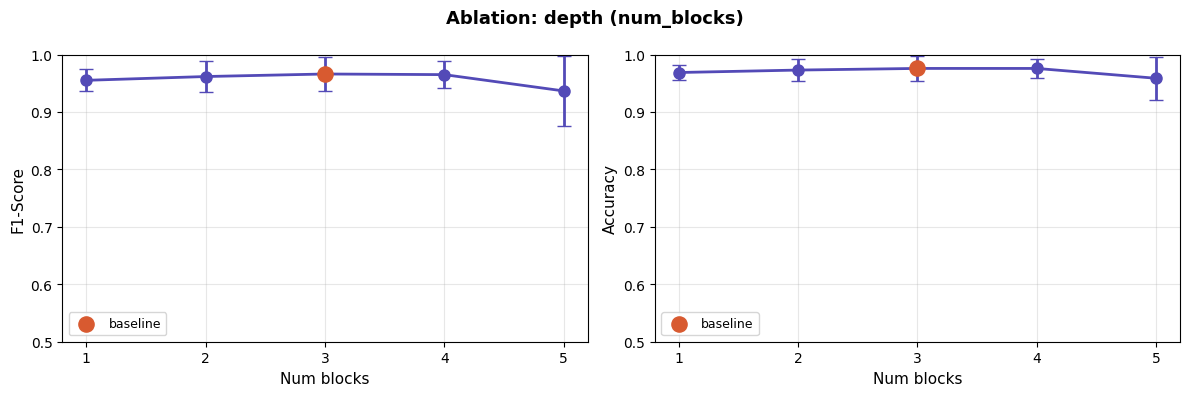

  ✓ p2_depth.png saved


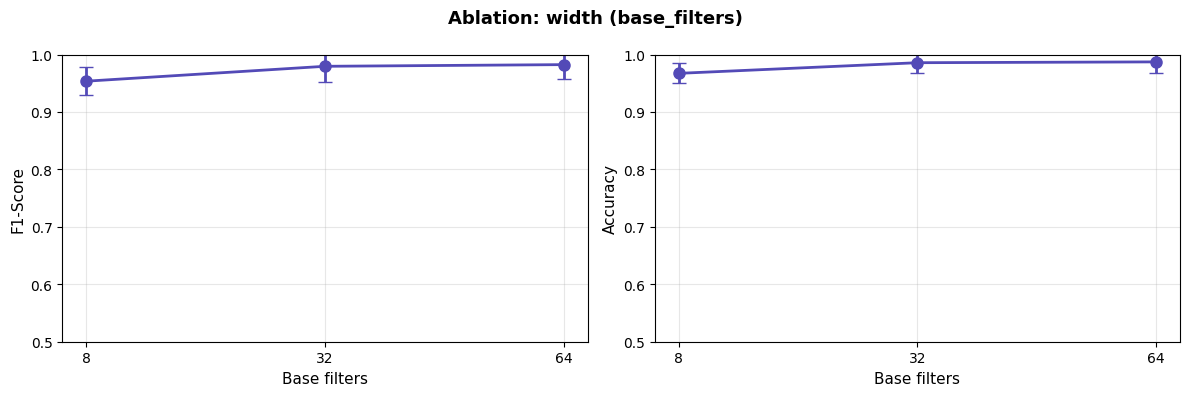

  ✓ p2_filters.png saved


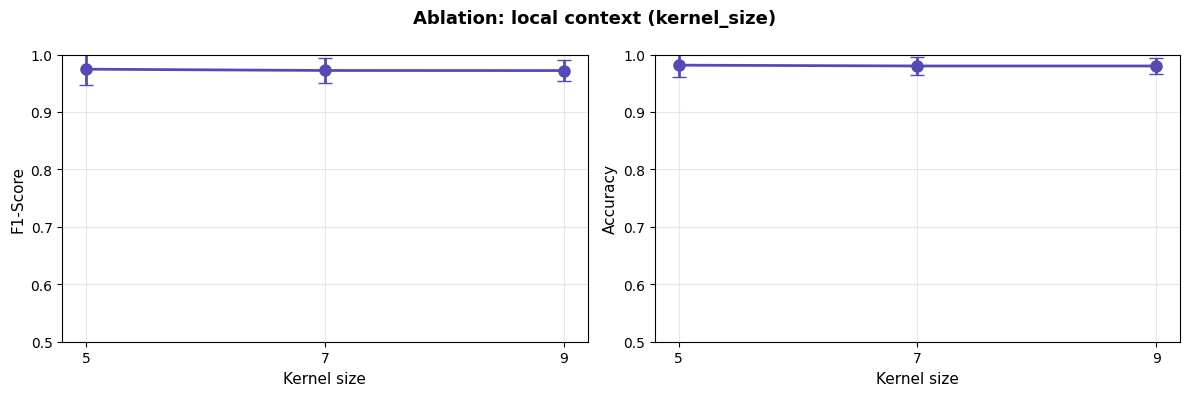

  ✓ p2_kernel.png saved


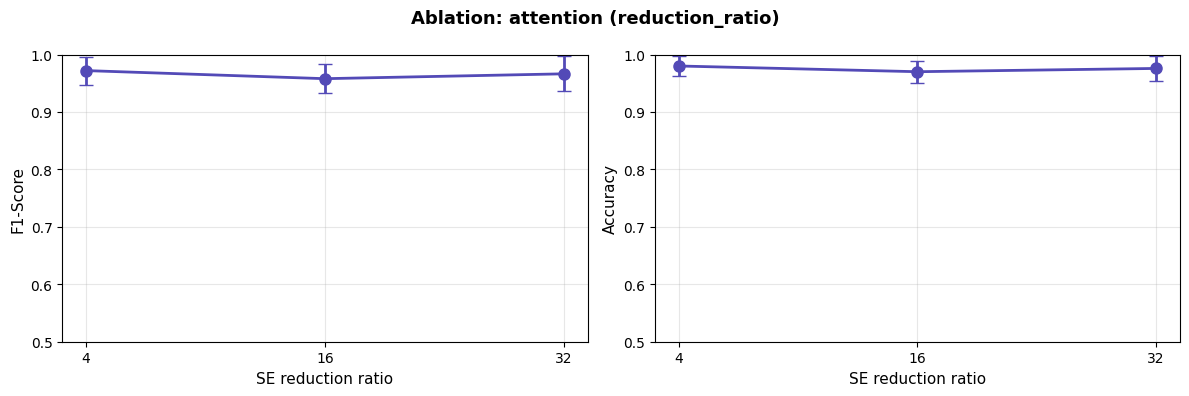

  ✓ p2_reduction.png saved


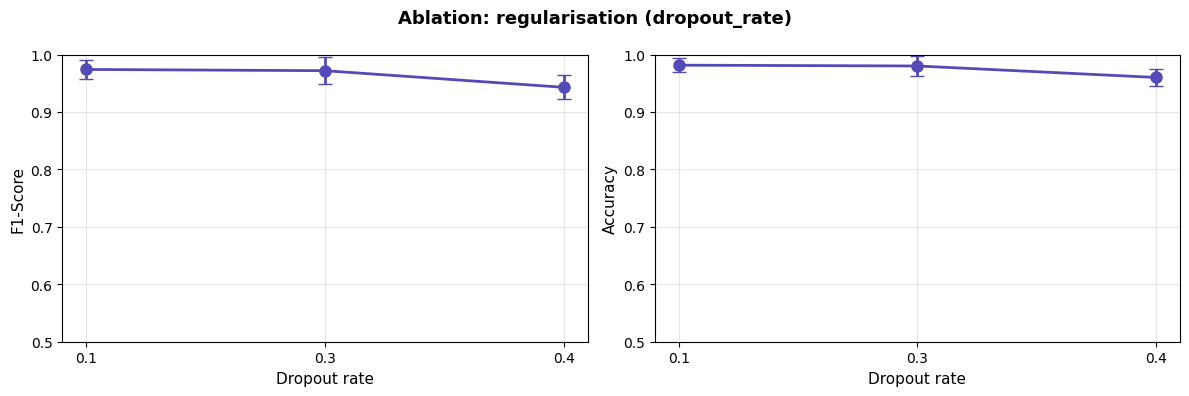

  ✓ p2_dropout.png saved


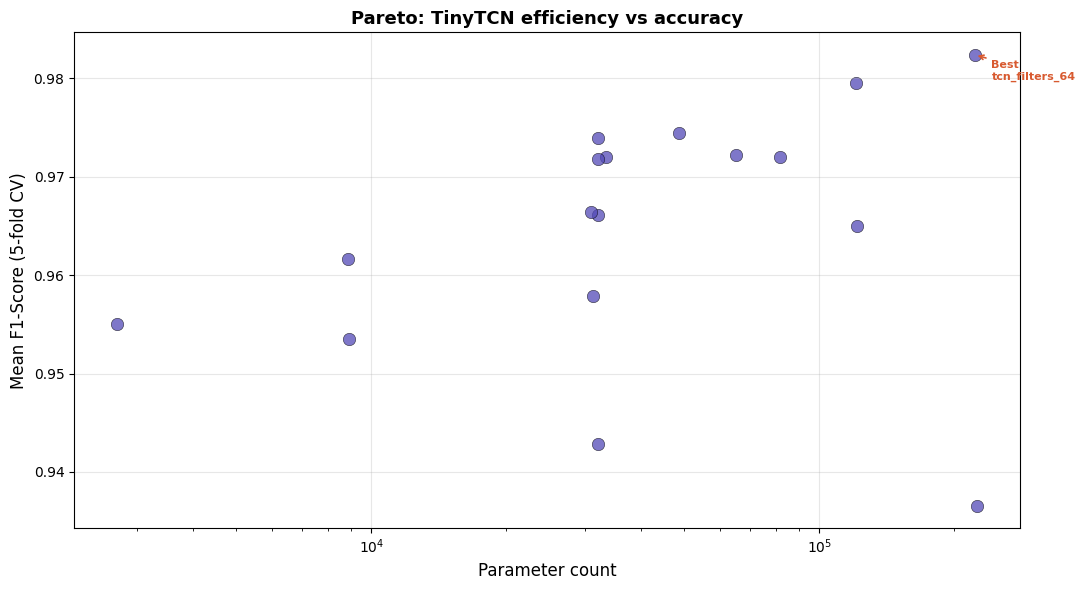


BEST HYPERPARAMETER CONFIG (by mean F1):
  Run             : tcn_filters_64
  num_blocks      : 3
  base_filters    : 64
  kernel_size     : 3
  reduction_ratio : 8
  dropout_rate    : 0.2
  Mean F1         : 0.9824 ± 0.0256
  Mean Accuracy   : 0.9872 ± 0.0188
  Parameters      : 222,538


In [31]:
# ============================================================
# Cell 10 — Part 2 Results & Visualisation
# ============================================================

def axis_plot(df, prefix, col, xlabel, title, fname):
    """Per-axis error-bar plot for F1 and Accuracy."""
    sub = df[df['run'].str.startswith(prefix)].copy()
    sub[col] = pd.to_numeric(sub[col])
    sub = sub.sort_values(col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, metric, std_col, ylabel in [
        (axes[0], 'mean_f1',  'std_f1',  'F1-Score'),
        (axes[1], 'mean_acc', 'std_acc', 'Accuracy'),
    ]:
        ax.errorbar(sub[col].astype(str), sub[metric],
                    yerr=sub[std_col],
                    fmt='o-', capsize=5, linewidth=2,
                    markersize=8, color='#534AB7')
        # Highlight baseline value
        base_val = TCN_BASELINE[col]
        base_row = sub[sub[col] == base_val]
        if not base_row.empty:
            ax.scatter([str(base_val)],
                       base_row[metric].values,
                       s=120, zorder=5, color='#D85A30',
                       label='baseline')
            ax.legend(fontsize=9)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_ylim(0.5, 1.0)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/{fname}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✓ {fname}.png saved")


print("Per-axis plots:")
axis_plot(hyper_df, 'tcn_blocks',    'num_blocks',
          'Num blocks',    'Ablation: depth (num_blocks)',
          'p2_depth')
axis_plot(hyper_df, 'tcn_filters',   'base_filters',
          'Base filters',  'Ablation: width (base_filters)',
          'p2_filters')
axis_plot(hyper_df, 'tcn_kernel',    'kernel_size',
          'Kernel size',   'Ablation: local context (kernel_size)',
          'p2_kernel')
axis_plot(hyper_df, 'tcn_reduction', 'reduction_ratio',
          'SE reduction ratio', 'Ablation: attention (reduction_ratio)',
          'p2_reduction')
axis_plot(hyper_df, 'tcn_dropout',   'dropout_rate',
          'Dropout rate',  'Ablation: regularisation (dropout_rate)',
          'p2_dropout')

# ── Pareto plot: F1 vs parameter count ──────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(hyper_df['params'], hyper_df['mean_f1'],
           c='#534AB7', s=80, alpha=0.75,
           edgecolors='k', linewidth=0.4)

best_row = hyper_df.loc[hyper_df['mean_f1'].idxmax()]
ax.annotate(
    f"Best\n{best_row['run']}",
    (best_row['params'], best_row['mean_f1']),
    fontsize=8, color='#D85A30', fontweight='bold',
    xytext=(12, -18), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.2)
)

ax.set_xlabel('Parameter count', fontsize=12)
ax.set_ylabel('Mean F1-Score (5-fold CV)', fontsize=12)
ax.set_title('Pareto: TinyTCN efficiency vs accuracy',
             fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/p2_pareto.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Best config summary ──────────────────────────────────────
print("\n" + "="*60)
print("BEST HYPERPARAMETER CONFIG (by mean F1):")
print("="*60)
print(f"  Run             : {best_row['run']}")
print(f"  num_blocks      : {int(best_row['num_blocks'])}")
print(f"  base_filters    : {int(best_row['base_filters'])}")
print(f"  kernel_size     : {int(best_row['kernel_size'])}")
print(f"  reduction_ratio : {int(best_row['reduction_ratio'])}")
print(f"  dropout_rate    : {float(best_row['dropout_rate'])}")
print(f"  Mean F1         : {best_row['mean_f1']:.4f} "
      f"± {best_row['std_f1']:.4f}")
print(f"  Mean Accuracy   : {best_row['mean_acc']:.4f} "
      f"± {best_row['std_acc']:.4f}")
print(f"  Parameters      : {int(best_row['params']):,}")

## Cell 11 — Final Model Training and Held-Out Test Set Evaluation

The optimal TinyTCN configuration confirmed by the two-part ablation study
is retrained in this cell on the complete training partition and evaluated
once on the held-out test set that was withheld from all ablation runs,
producing the primary performance claim of the study. Retraining on the
full training set, rather than on a single cross-validation fold, allows
the model to benefit from the maximum available volume of labelled
physiological data, which is expected to improve the calibration of the
learned representations and reduce the variance of the final parameter
estimates relative to any individual fold model. Early stopping is applied
with the training loss as the monitored metric, rather than a validation
loss, since no data is withheld from training during this stage; the
model checkpoint corresponding to the lowest observed training loss is
reloaded before test set inference to ensure that reported metrics
correspond to a stable training state rather than a potentially degraded
final epoch. The test set evaluation is performed exactly once, and the
resulting accuracy, F1-score, precision, and recall values constitute the
reported generalisation performance of the proposed model, as they are
derived from data that exerted no influence on any stage of the model
selection or training process. The confusion matrix visualisation
complements the scalar metrics by revealing the distribution of
classification errors between the baseline and stress classes, which is
of practical importance in physiological stress monitoring applications
where false-negative errors — stress episodes misclassified as baseline —
carry different clinical implications from false-positive errors. The
confirmed architectural configuration, scalar performance metrics, and
model size in kilobytes are serialised to a structured JSON file, producing
a stable and auditable record that serves as the authoritative reference
for the quantization and deployment analysis conducted in the following cell.

Final TinyTCN config: {'num_blocks': 3, 'base_filters': 64, 'kernel_size': 3, 'reduction_ratio': 8, 'dropout_rate': 0.2}


Model: "TinyTCN_Final"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape     ┃   Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer) │ (None, 480, 6)   │         0 │ -                │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ entry_conv         │ (None, 480, 64)  │     1,152 │ input[0][0]      │
│ (Conv1D)           │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ entry_bn           │ (None, 480, 64)  │       256 │ entry_conv[0][0] │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ entry_relu (ReLU)  │ (None, 480, 64)  │         0 │ entry_bn[0][0]   │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_c1 (Conv1D)     │ (None, 480, 64)  │    12,288 │ entry_relu[0][0] │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_bn1             │ (None, 480, 64)  │       256 │ b1_c1[0][0]      │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_r1 (ReLU)       │ (None, 480, 64)  │         0 │ b1_bn1[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_drop (Dropout)  │ (None, 480, 64)  │         0 │ b1_r1[0][0]      │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_c2 (Conv1D)     │ (None, 480, 64)  │    12,288 │ b1_drop[0][0]    │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_bn2             │ (None, 480, 64)  │       256 │ b1_c2[0][0]      │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_add (Add)       │ (None, 480, 64)  │         0 │ b1_bn2[0][0],    │
│                    │                  │           │ entry_relu[0][0] │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b1_r2 (ReLU)       │ (None, 480, 64)  │         0 │ b1_add[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_sq           │ (None, 64)       │         0 │ b1_r2[0][0]      │
│ (GlobalAveragePoo… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_fc1 (Dense)  │ (None, 8)        │       520 │ attn1_sq[0][0]   │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_fc2 (Dense)  │ (None, 64)       │       576 │ attn1_fc1[0][0]  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_rs (Reshape) │ (None, 1, 64)    │         0 │ attn1_fc2[0][0]  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn1_mul          │ (None, 480, 64)  │         0 │ b1_r2[0][0],     │
│ (Multiply)         │                  │           │ attn1_rs[0][0]   │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ pool1              │ (None, 240, 64)  │         0 │ attn1_mul[0][0]  │
│ (MaxPooling1D)     │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_c1 (Conv1D)     │ (None, 240, 128) │    24,576 │ pool1[0][0]      │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_bn1             │ (None, 240, 128) │       512 │ b2_c1[0][0]      │
│ (BatchNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_r1 (ReLU)       │ (None, 240, 128) │         0 │ b2_bn1[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ b2_drop (Dropout)  │ (None, 240, 128) │         0 │ b2_r

 Total params: 222,538 (869.29 KB)

 Trainable params: 221,130 (863.79 KB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.7461 - loss: 0.5510 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8659 - loss: 0.4140 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9016 - loss: 0.3757 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8973 - loss: 0.3810 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9044 - loss: 0.3579 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9144 - loss: 0.3469 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9315 - loss: 0.3244 - learning_rate: 0.0010
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9501 - loss: 0.2935 - learning_rate: 0.0010
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9486 - loss: 0.2973 - learning_rate: 0.0010
Epoch 10/1

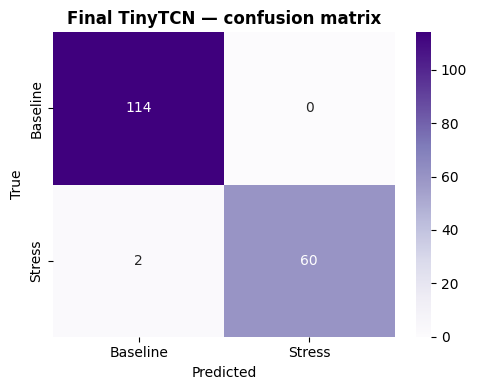


✓ Final metrics saved to final_metrics.json


In [32]:
# ============================================================
# Cell 11 — Final Proposed TinyTCN
# Retrain best config on full train set → evaluate on held-out
# test set → save Keras model
# ============================================================

keras.backend.clear_session()
gc.collect()

BEST = {
    'num_blocks':      int(best_row['num_blocks']),
    'base_filters':    int(best_row['base_filters']),
    'kernel_size':     int(best_row['kernel_size']),
    'reduction_ratio': int(best_row['reduction_ratio']),
    'dropout_rate':    float(best_row['dropout_rate']),
}
print("Final TinyTCN config:", BEST)

final_model = build_tiny_tcn(
    input_shape     = INPUT_SHAPE,
    num_blocks      = BEST['num_blocks'],
    base_filters    = BEST['base_filters'],
    kernel_size     = BEST['kernel_size'],
    dropout_rate    = BEST['dropout_rate'],
    reduction_ratio = BEST['reduction_ratio'],
    use_residual    = True,
    use_attention   = True,
    use_pooling     = True,
    model_name      = 'TinyTCN_Final'
)
final_model.compile(
    optimizer=optimizers.Adam(LR, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
final_model.summary(line_length=72)

y_train_cat = (to_categorical(y_train, 2)
               * (1 - LABEL_SMOOTH) + LABEL_SMOOTH / 2)

final_ckpt = os.path.join(MODEL_DIR, 'tinytcn_final.keras')
final_model.fit(
    X_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='loss', patience=PATIENCE,
            restore_best_weights=True),
        callbacks.ReduceLROnPlateau(
            monitor='loss', factor=0.5,
            patience=8, min_lr=1e-6, verbose=0),
        callbacks.ModelCheckpoint(
            final_ckpt, monitor='loss',
            save_best_only=True, verbose=0),
    ],
    verbose=1
)

final_model = keras.models.load_model(final_ckpt)

# ── Test set evaluation ──────────────────────────────────────
y_pred_prob = final_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

test_acc  = accuracy_score(y_test, y_pred)
prec, rec, test_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='binary', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "="*60)
print("FINAL MODEL — TEST SET RESULTS")
print("="*60)
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  F1-Score  : {test_f1:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  Params    : {final_model.count_params():,}")
print(f"  Keras size: "
      f"{os.path.getsize(final_ckpt)/1024:.1f} KB")

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Baseline','Stress'],
            yticklabels=['Baseline','Stress'],
            ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Final TinyTCN — confusion matrix',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/final_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save final metrics
final_metrics = {
    'config':       BEST,
    'test_accuracy': float(test_acc),
    'test_f1':       float(test_f1),
    'test_precision':float(prec),
    'test_recall':   float(rec),
    'params':        int(final_model.count_params()),
    'keras_size_kb': round(os.path.getsize(final_ckpt)/1024, 2),
}
with open(f'{SAVE_DIR}/final_metrics.json', 'w') as fp:
    json.dump(final_metrics, fp, indent=2)
print("\n✓ Final metrics saved to final_metrics.json")

## Cell 12 — TFLite Conversion, Post-Training Quantization, and Deployment Analysis

The confirmed final TinyTCN model is converted to the TensorFlow Lite
deployment format in this cell using all three supported post-training
quantization strategies, enabling a comprehensive empirical characterisation
of the accuracy-size tradeoff associated with each level of numerical
precision reduction. Full INT8 quantization reduces both the stored model
weights and the runtime activation tensors to eight-bit signed integers,
producing the smallest possible model footprint and enabling execution on
microcontrollers equipped with dedicated integer arithmetic units, such as
those implementing the ARM CMSIS-NN library on Cortex-M series processors.
This strategy requires a representative calibration dataset, drawn in this
study from the training partition, to determine per-layer activation
distributions and compute the affine quantization parameters — scale and
zero-point — that govern the mapping between floating-point and integer
representations at each layer boundary. Float16 quantization reduces the
precision of stored weight tensors to sixteen-bit floating-point values
while retaining full float32 precision for runtime activations, yielding
an approximately two-fold reduction in model storage size relative to the
float32 baseline without requiring integer arithmetic support on the target
processor, and is therefore appropriate for deployment on devices with
native float16 acceleration. Dynamic range quantization compresses stored
weights to INT8 at conversion time but dequantizes them to float32 at
inference time, operating on float32 inputs without requiring a calibration
dataset; this strategy introduces the least perturbation to the inference
computation but achieves a smaller storage reduction than full INT8. Each
converted model is evaluated on the identical held-out test set using a
dtype-aware inference routine that correctly applies input quantization and
output dequantization where required by the specific quantization scheme,
ensuring that all reported accuracy and F1-score values reflect true
end-to-end quantized inference performance rather than idealised float32
surrogate metrics. A composite scoring function that weights the normalised
size reduction and normalised F1-score retention equally across the three
quantized variants is employed to identify and report the recommended
deployment strategy, providing a principled and reproducible basis for the
deployment decision that is appropriate to the TinyML context of this
research. All conversion outcomes, evaluation metrics, compression ratios,
and accuracy drops relative to the float32 baseline are consolidated into
a structured JSON report, constituting a complete and auditable record of
the quantization study and providing the numerical evidence required to
support deployment claims in a research publication.

TFLite Conversion — All Three Strategies

── Strategy 1: Full INT8 ──────────────────────────────
INFO:tensorflow:Assets written to: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmp_hmyqgza/assets


INFO:tensorflow:Assets written to: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmp_hmyqgza/assets


Saved artifact at '/var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmp_hmyqgza'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 480, 6), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  15611835408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611831952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611833872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611834256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611825424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611835024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611828496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611823504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611835792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611833104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611831184: TensorSpe

W0000 00:00:1773856189.682586  957863 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773856189.683762  957863 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-18 23:19:49.686064: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmp_hmyqgza
2026-03-18 23:19:49.688060: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-18 23:19:49.688090: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmp_hmyqgza
2026-03-18 23:19:49.704984: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-18 23:19:49.792500: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmp_hmyqgza
2026-03-18 23:19:49.812570: I tensorflow/cc/saved_model/loader.cc:

  ✓ Success — 267.35 KB
    input  dtype=<class 'numpy.int8'>  scale=0.405500  zero_point=28
    output dtype=<class 'numpy.int8'>

── Strategy 2: Float16 ────────────────────────────────
INFO:tensorflow:Assets written to: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmp80h7jtod/assets


...

  ✓ Success — 451.49 KB
    input  dtype=<class 'numpy.float32'>
    output dtype=<class 'numpy.float32'>

── Strategy 3: Dynamic range ──────────────────────────
INFO:tensorflow:Assets written to: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmpq_99dh25/assets


INFO:tensorflow:Assets written to: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmpq_99dh25/assets


Saved artifact at '/var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmpq_99dh25'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 480, 6), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  15611835408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611831952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611833872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611834256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611825424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611835024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611828496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611823504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611835792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611833104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  15611831184: TensorSpe

W0000 00:00:1773856200.226517  957863 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773856200.226530  957863 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-18 23:20:00.226649: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmpq_99dh25
2026-03-18 23:20:00.227884: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-18 23:20:00.227889: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmpq_99dh25
2026-03-18 23:20:00.240860: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-18 23:20:00.304612: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/t2/x4nm4js51z16mc80hbf126qh0000gn/T/tmpq_99dh25
2026-03-18 23:20:00.323353: I tensorflow/cc/saved_model/loader.cc:

  ✓ Success — 253.16 KB
    input  dtype=<class 'numpy.float32'>
    output dtype=<class 'numpy.float32'>

Evaluating on test set …

  INT8 …
    Accuracy : 0.7955  (drop: +0.1932)
    F1-Score : 0.7692  (drop: +0.2144)

  Float16 …
    Accuracy : 0.9886  (drop: +0.0000)
    F1-Score : 0.9836  (drop: +0.0000)

  Dynamic …
    Accuracy : 0.9886  (drop: +0.0000)
    F1-Score : 0.9836  (drop: +0.0000)

FULL QUANTIZATION COMPARISON TABLE
          Strategy  Size (KB) Compression  Accuracy  Acc drop     F1  F1 drop             Input dtype
Float32 (baseline)    2789.37        1.0x    0.9886    0.0000 0.9836   0.0000                 float32
              INT8     267.35       10.43    0.7955    0.1932 0.7692   0.2144    <class 'numpy.int8'>
           Float16     451.49        6.18    0.9886    0.0000 0.9836   0.0000 <class 'numpy.float32'>
           Dynamic     253.16       11.02    0.9886    0.0000 0.9836   0.0000 <class 'numpy.float32'>


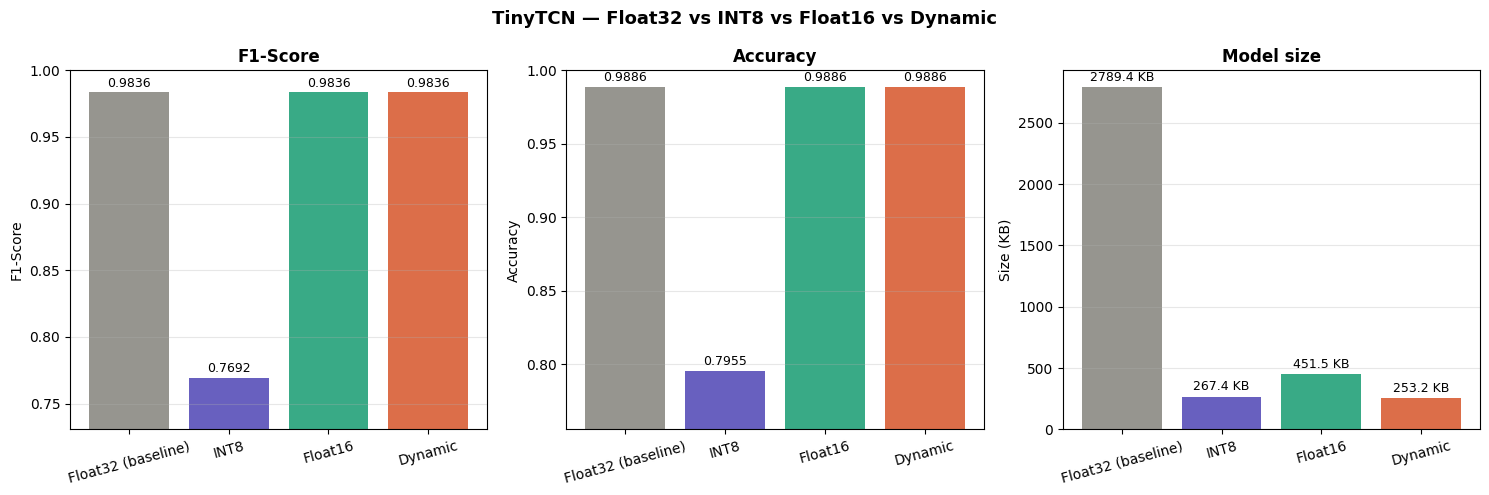


RECOMMENDATION
  Best overall strategy : Dynamic
  Size                  : 253.16 KB  (11.02x compression)
  F1-Score              : 0.9836  (drop: +0.0)
  Accuracy              : 0.9886  (drop: +0.0)
  Deployable file       : tinytcn_ablation/tflite/tinytcn_dynamic.tflite

✓ Full report saved to tflite_full_report.json
✓ All .tflite files saved to tinytcn_ablation/tflite/


In [34]:
# ============================================================
# Cell 12 — TFLite Conversion (All Three Strategies)
# Runs INT8, Float16, and Dynamic Range independently.
# Each is evaluated on the test set and compared side by side.
# ============================================================

def representative_dataset_gen(X, n=500):
    """Yields float32 samples for INT8 calibration."""
    idx = np.random.choice(len(X), min(n, len(X)), replace=False)
    for i in idx:
        yield [X[i:i+1].astype(np.float32)]


def convert_int8(keras_model, X_rep, save_dir, model_name):
    """Full INT8 quantization — smallest size, needs calibration."""
    print("\n── Strategy 1: Full INT8 ──────────────────────────────")
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = \
            lambda: representative_dataset_gen(X_rep)
        converter.target_spec.supported_ops = \
            [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type  = tf.int8
        converter.inference_output_type = tf.int8

        tflite_model = converter.convert()

        # Sanity check
        interp = tf.lite.Interpreter(model_content=tflite_model)
        interp.allocate_tensors()
        inp = interp.get_input_details()[0]
        out = interp.get_output_details()[0]
        sc, zp = inp['quantization']

        test_in = X_rep[:1].astype(np.float32)
        if sc > 0:
            test_in = np.clip(
                test_in / sc + zp, -128, 127).astype(np.int8)
        interp.set_tensor(inp['index'], test_in)
        interp.invoke()

        path = os.path.join(save_dir, f'{model_name}_int8.tflite')
        with open(path, 'wb') as f:
            f.write(tflite_model)

        size_kb = len(tflite_model) / 1024
        print(f"  ✓ Success — {size_kb:.2f} KB")
        print(f"    input  dtype={inp['dtype']}  "
              f"scale={sc:.6f}  zero_point={zp}")
        print(f"    output dtype={out['dtype']}")

        return {
            'success': True, 'strategy': 'INT8',
            'path': path, 'size_kb': size_kb,
            'input_scale': float(sc),
            'input_zero_point': int(zp),
            'input_dtype': str(inp['dtype']),
            'output_dtype': str(out['dtype']),
        }

    except Exception as e:
        print(f"  ✗ Failed: {e}")
        return {'success': False, 'strategy': 'INT8', 'error': str(e)}


def convert_float16(keras_model, save_dir, model_name):
    """Float16 quantization — weights halved, activations float32."""
    print("\n── Strategy 2: Float16 ────────────────────────────────")
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

        tflite_model = converter.convert()

        # Sanity check
        interp = tf.lite.Interpreter(model_content=tflite_model)
        interp.allocate_tensors()
        inp = interp.get_input_details()[0]
        out = interp.get_output_details()[0]

        test_in = np.random.randn(1, *inp['shape'][1:]).astype(np.float32)
        interp.set_tensor(inp['index'], test_in)
        interp.invoke()

        path = os.path.join(save_dir, f'{model_name}_float16.tflite')
        with open(path, 'wb') as f:
            f.write(tflite_model)

        size_kb = len(tflite_model) / 1024
        print(f"  ✓ Success — {size_kb:.2f} KB")
        print(f"    input  dtype={inp['dtype']}")
        print(f"    output dtype={out['dtype']}")

        return {
            'success': True, 'strategy': 'Float16',
            'path': path, 'size_kb': size_kb,
            'input_scale': 1.0, 'input_zero_point': 0,
            'input_dtype': str(inp['dtype']),
            'output_dtype': str(out['dtype']),
        }

    except Exception as e:
        print(f"  ✗ Failed: {e}")
        return {'success': False, 'strategy': 'Float16', 'error': str(e)}


def convert_dynamic(keras_model, save_dir, model_name):
    """Dynamic range quantization — no calibration needed."""
    print("\n── Strategy 3: Dynamic range ──────────────────────────")
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

        tflite_model = converter.convert()

        # Sanity check
        interp = tf.lite.Interpreter(model_content=tflite_model)
        interp.allocate_tensors()
        inp = interp.get_input_details()[0]
        out = interp.get_output_details()[0]

        test_in = np.random.randn(1, *inp['shape'][1:]).astype(inp['dtype'])
        interp.set_tensor(inp['index'], test_in)
        interp.invoke()

        path = os.path.join(save_dir, f'{model_name}_dynamic.tflite')
        with open(path, 'wb') as f:
            f.write(tflite_model)

        size_kb = len(tflite_model) / 1024
        print(f"  ✓ Success — {size_kb:.2f} KB")
        print(f"    input  dtype={inp['dtype']}")
        print(f"    output dtype={out['dtype']}")

        return {
            'success': True, 'strategy': 'Dynamic',
            'path': path, 'size_kb': size_kb,
            'input_scale': 1.0, 'input_zero_point': 0,
            'input_dtype': str(inp['dtype']),
            'output_dtype': str(out['dtype']),
        }

    except Exception as e:
        print(f"  ✗ Failed: {e}")
        return {'success': False, 'strategy': 'Dynamic', 'error': str(e)}


def evaluate_tflite(tflite_path, X_test, y_test):
    """
    Run inference on full test set.
    Handles INT8, float16, and float32 input/output dtypes.
    """
    interp = tf.lite.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]

    in_scale,  in_zp  = inp['quantization']
    out_scale, out_zp = out['quantization']
    in_dtype           = inp['dtype']
    out_dtype          = out['dtype']

    preds = []
    for i in range(len(X_test)):
        x = X_test[i:i+1].astype(np.float32)

        # Quantize input if needed
        if in_dtype == np.int8 and in_scale > 0:
            x = np.clip(x / in_scale + in_zp,
                        -128, 127).astype(np.int8)
        elif in_dtype == np.uint8 and in_scale > 0:
            x = np.clip(x / in_scale + in_zp,
                        0, 255).astype(np.uint8)
        else:
            x = x.astype(in_dtype)

        interp.set_tensor(inp['index'], x)
        interp.invoke()
        o = interp.get_tensor(out['index'])

        # Dequantize output if needed
        if out_dtype in (np.int8, np.uint8) and out_scale > 0:
            o = (o.astype(np.float32) - out_zp) * out_scale

        preds.append(np.argmax(o))

    preds = np.array(preds)
    acc   = accuracy_score(y_test, preds)
    _, _, f1, _ = precision_recall_fscore_support(
        y_test, preds, average='binary', zero_division=0)
    return {'accuracy': acc, 'f1': f1}


# ── Run all three conversions ─────────────────────────────────
print("=" * 60)
print("TFLite Conversion — All Three Strategies")
print("=" * 60)

keras_kb = os.path.getsize(final_ckpt) / 1024

results_int8    = convert_int8(final_model, X_train,
                               TFLITE_DIR, 'tinytcn')
results_float16 = convert_float16(final_model,
                                  TFLITE_DIR, 'tinytcn')
results_dynamic = convert_dynamic(final_model,
                                  TFLITE_DIR, 'tinytcn')

# ── Evaluate each successful conversion ──────────────────────
print("\n" + "=" * 60)
print("Evaluating on test set …")
print("=" * 60)

all_conv = [results_int8, results_float16, results_dynamic]
rows = []

for conv in all_conv:
    if conv['success']:
        print(f"\n  {conv['strategy']} …")
        m = evaluate_tflite(conv['path'], X_test, y_test)
        conv['test_acc'] = m['accuracy']
        conv['test_f1']  = m['f1']
        print(f"    Accuracy : {m['accuracy']:.4f}  "
              f"(drop: {test_acc - m['accuracy']:+.4f})")
        print(f"    F1-Score : {m['f1']:.4f}  "
              f"(drop: {test_f1 - m['f1']:+.4f})")
        rows.append({
            'Strategy':       conv['strategy'],
            'Size (KB)':      round(conv['size_kb'], 2),
            'Compression':    round(keras_kb / conv['size_kb'], 2),
            'Accuracy':       round(m['accuracy'], 4),
            'Acc drop':       round(test_acc - m['accuracy'], 4),
            'F1':             round(m['f1'], 4),
            'F1 drop':        round(test_f1 - m['f1'], 4),
            'Input dtype':    conv['input_dtype'],
        })
    else:
        rows.append({
            'Strategy':    conv['strategy'],
            'Size (KB)':   'failed',
            'Compression': '-',
            'Accuracy':    '-',
            'Acc drop':    '-',
            'F1':          '-',
            'F1 drop':     '-',
            'Input dtype': '-',
        })

# Add float32 baseline row for reference
rows.insert(0, {
    'Strategy':    'Float32 (baseline)',
    'Size (KB)':   round(keras_kb, 2),
    'Compression': '1.0x',
    'Accuracy':    round(test_acc, 4),
    'Acc drop':    0.0,
    'F1':          round(test_f1, 4),
    'F1 drop':     0.0,
    'Input dtype': 'float32',
})

summary_df = pd.DataFrame(rows)
summary_df.to_csv(f'{SAVE_DIR}/tflite_comparison.csv', index=False)

print("\n" + "=" * 60)
print("FULL QUANTIZATION COMPARISON TABLE")
print("=" * 60)
print(summary_df.to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────
successful = [r for r in rows if r['Size (KB)'] != 'failed']
strategies = [r['Strategy'] for r in successful]
sizes      = [float(r['Size (KB)']) for r in successful]
f1s        = [float(r['F1']) for r in successful]
accs       = [float(r['Accuracy']) for r in successful]
colors     = ['#888780', '#534AB7', '#1D9E75', '#D85A30'][:len(successful)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TinyTCN — Float32 vs INT8 vs Float16 vs Dynamic',
             fontsize=13, fontweight='bold')

# F1 comparison
bars = axes[0].bar(strategies, f1s, color=colors, alpha=0.88)
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(min(f1s) * 0.95, 1.0)
axes[0].set_title('F1-Score', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Accuracy comparison
bars = axes[1].bar(strategies, accs, color=colors, alpha=0.88)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(min(accs) * 0.95, 1.0)
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Size comparison
bars = axes[2].bar(strategies, sizes, color=colors, alpha=0.88)
axes[2].set_ylabel('Size (KB)')
axes[2].set_title('Model size', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, sizes):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + keras_kb * 0.01,
                 f'{v:.1f} KB', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/tflite_all_strategies.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Recommend best strategy ───────────────────────────────────
print("\n" + "=" * 60)
print("RECOMMENDATION")
print("=" * 60)

# Score each successful quantized strategy (exclude float32 baseline)
# by combining smallest size and highest F1
quantized = [r for r in successful if r['Strategy'] != 'Float32 (baseline)']
if quantized:
    # Normalise size (smaller = better) and F1 (higher = better)
    min_sz = min(float(r['Size (KB)']) for r in quantized)
    max_f1 = max(float(r['F1']) for r in quantized)
    scored = []
    for r in quantized:
        sz_score = min_sz / float(r['Size (KB)'])   # 1.0 = smallest
        f1_score = float(r['F1']) / max_f1           # 1.0 = best F1
        score    = 0.5 * sz_score + 0.5 * f1_score
        scored.append((score, r))
    best = max(scored, key=lambda x: x[0])[1]

    print(f"  Best overall strategy : {best['Strategy']}")
    print(f"  Size                  : {best['Size (KB)']} KB  "
          f"({best['Compression']}x compression)")
    print(f"  F1-Score              : {best['F1']}  "
          f"(drop: {best['F1 drop']:+})")
    print(f"  Accuracy              : {best['Accuracy']}  "
          f"(drop: {best['Acc drop']:+})")
    print(f"  Deployable file       : "
          f"{[c['path'] for c in all_conv if c['success'] and c['strategy'] == best['Strategy']][0]}")

# Save full report
report = {
    'float32_baseline': {
        'accuracy': float(test_acc),
        'f1':       float(test_f1),
        'size_kb':  round(keras_kb, 2),
        'params':   int(final_model.count_params()),
    },
    'quantization_results': [
        {k: v for k, v in c.items() if k != 'path'}
        for c in all_conv
    ],
    'comparison_table': rows,
}
with open(f'{SAVE_DIR}/tflite_full_report.json', 'w') as fp:
    json.dump(report, fp, indent=2, default=str)
print("\n✓ Full report saved to tflite_full_report.json")
print(f"✓ All .tflite files saved to {TFLITE_DIR}/")